In here, we will explore ensemble methods for machine learning, basically having a *group of predictors/ classifers* and then doing a majority voting

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=500, noise= 0.30, random_state= 42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 42)

voting_clf = VotingClassifier(
    estimators = [
        ('lr', LogisticRegression(random_state= 42)), 
        ('rf', RandomForestClassifier(random_state= 42)), 
        ('svc', SVC(random_state= 42))
    ]
)
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(random_state=42))])

In [3]:
voting_clf.estimators

[('lr', LogisticRegression(random_state=42)),
 ('rf', RandomForestClassifier(random_state=42)),
 ('svc', SVC(random_state=42))]

In [4]:
voting_clf.named_estimators_.items()

dict_items([('lr', LogisticRegression(random_state=42)), ('rf', RandomForestClassifier(random_state=42)), ('svc', SVC(random_state=42))])

In [5]:
for name, clf in voting_clf.named_estimators_.items():
    print(name, "=", clf.score(X_test, y_test))

lr = 0.864
rf = 0.896
svc = 0.896


so each of them individually has an **86-89%** accuracy on the test set...

In [6]:
voting_clf.score(X_test, y_test)

0.912

voting classifer outperforms them all

In [7]:
voting_clf.predict(X_test[:1])


array([1], dtype=int64)

In [8]:
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([1], dtype=int64), array([1], dtype=int64), array([0], dtype=int64)]

The voting classifier right performs what we call **hard** voting... just a majority of votes

**soft** voting is when it gets the probabilities from each classifer and avergaes them out to give the predicition.. Higher probability for a classifier gets a *higher weight*

In [9]:
voting_clf.voting= "soft"
voting_clf.named_estimators["svc"].probability = True
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

0.92

so, soft voting outperforms hard voting.. may not be always true (overfitting) but worth a look

So far, we have aggregated predictors... train each on the training set and then vote a majority

Another key technique is bagging/ pasting.. in here, we train, perhaps even the same predictors on different random subsets of the training set

only diff is, **Bagging** allows for sampling **with replacement** (where an instance can be repeated in any one subset training a particular classifier) while in **Pasting**, that's not allowed

**Bagging/ Pasting**

In [10]:
#Bagging
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf= BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, max_samples=100, n_jobs= -1, random_state=
                          42) ## n_jobs= -1 tells it to use all available CPU cores
bag_clf.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=100,
                  n_estimators=500, n_jobs=-1, random_state=42)

In [11]:
#Pasting
past_clf= BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, max_samples=100, n_jobs= -1, bootstrap= False,random_state=42) #bootstrap set to false
past_clf.fit(X_train, y_train)

BaggingClassifier(bootstrap=False, estimator=DecisionTreeClassifier(),
                  max_samples=100, n_estimators=500, n_jobs=-1,
                  random_state=42)

In [12]:
dec_tree= DecisionTreeClassifier(random_state=42)
dec_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [13]:
def plot_decision_boundary(clf, X, y, axes): 
    xmin= X_train[:,0].min()
    xmax= X_train[:,0].max()
    ymin= X_train[:,1].min()
    ymax= X_train[:,1].max()

    axes= [xmin, xmax, ymin, ymax]
    
    x1, x2= np.meshgrid(np.linspace(axes[0], axes[1], 100), np.linspace(axes[2], axes[3], 100))
    X_new= np.c_[x1.ravel(), x2.ravel()]
    y_pred= clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha= 0.3, cmap= "Wistia")
    plt.contour(x1, x2, y_pred, cmap = "Greys", alpha= 0.8)

    colors = ["#78785c", "#c47b27"]
    markers= ("o", "^")

    for idx in (0,1):
        plt.plot(X[:,0][y==idx], X[:,1][y==idx],alpha= 0.5, color= colors[idx], marker= markers[idx], linestyle= "none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation= 0)

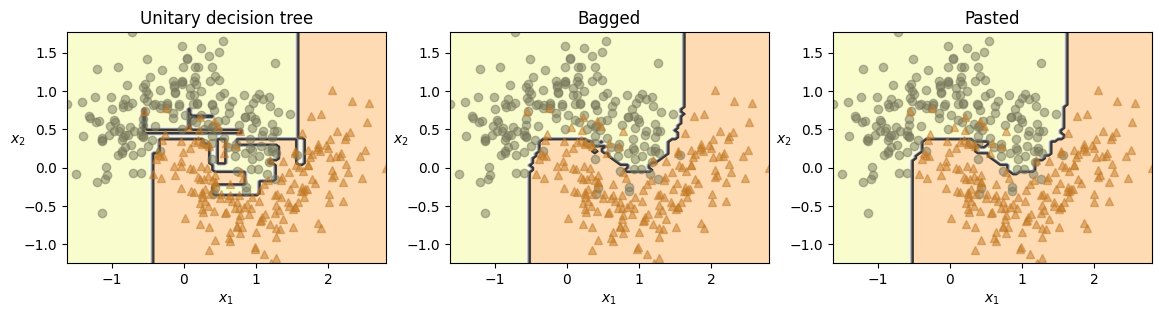

In [14]:
fig, axes= plt.subplots(1,3, figsize = (14,3))

plt.sca(axes[0])
plot_decision_boundary(dec_tree, X_train, y_train, axes)
plt.title("Unitary decision tree")

plt.sca(axes[1])
plot_decision_boundary(bag_clf, X_train, y_train, axes)
plt.title("Bagged")

plt.sca(axes[2])
plot_decision_boundary(past_clf, X_train, y_train, axes)
plt.title("Pasted")

plt.show()

You can see how both Bagging and Pasting are set to generalize much better than a single decision tree, but amongst the two it's little variation on the grooves... it's likely to keep chopping and changing between who wins over there

In [15]:
bag_clf= BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, oob_score= True, n_jobs= -1, random_state=
                          42) 
bag_clf.fit(X_train, y_train)


BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=500,
                  n_jobs=-1, oob_score=True, random_state=42)

In [16]:
bag_clf.oob_score_ ## out of bag evaluations.. on the instances a predictor was'nt trained on

0.896

In [17]:
from sklearn.metrics import accuracy_score
y_pred_bagged= bag_clf.predict(X_test)
accuracy_score(y_test, y_pred_bagged)

0.92

In [18]:
y_pred_pasted= past_clf.predict(X_test)
accuracy_score(y_test, y_pred_pasted)

0.92

Damn..

### Random Patches and Subspaces

This incorporates the idea of sampling features as well as instances

Sampling *both training instances and features* is called **Random Patches**  
Keeping all the training isntances but sampling *only features* is called **Random Subspaces**

In [19]:
X[:5]

array([[ 0.83103915, -0.25874875],
       [ 1.18506381,  0.92038714],
       [ 1.16402213, -0.45552558],
       [-0.0236556 ,  1.08628844],
       [ 0.48050273,  1.50942444]])

we only have two features....

In [20]:
ran_patch= BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, max_samples=0.5, max_features=0.5, oob_score= True, n_jobs= -1, random_state=
                          42) 
ran_patch.fit(X_train, y_train)

ran_sub= BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, max_samples=1.0, bootstrap= False, max_features=0.5, bootstrap_features=True, n_jobs= -1, random_state=42)
ran_sub.fit(X_train, y_train)

BaggingClassifier(bootstrap=False, bootstrap_features=True,
                  estimator=DecisionTreeClassifier(), max_features=0.5,
                  n_estimators=500, n_jobs=-1, random_state=42)

In [21]:
y_pred_patch= ran_patch.predict(X_test)
accuracy_score(y_test, y_pred_patch)

0.84

In [22]:
y_pred_sub= ran_sub.predict(X_test)
accuracy_score(y_test, y_pred_sub)

0.648

clearly as our data only had two features, it was never a good idea to do feature sampling.. so yeah.. 

### Random Forests

In [23]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, 
                                n_jobs=-1, random_state=42)
rnd_clf.fit(X_train, y_train)

y_pred_rf= rnd_clf.predict(X_test)

In [24]:
accuracy_score(y_test, y_pred_rf)

0.912

In [25]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features="sqrt", max_leaf_nodes=16), 
    n_estimators=500, n_jobs=-1, random_state=42
)

In [26]:
bag_clf.fit(X_train, y_train)
y_pred_newbag= bag_clf.predict(X_test)

accuracy_score(y_test, y_pred_newbag)

0.912

yeah, so it's kinda the same thing.. that's what we meant to show... not too much variation either as our current dataset only has 2 features available

In [27]:
random_bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features="sqrt", max_leaf_nodes=16, splitter = "random"), 
    n_estimators=500, n_jobs=-1, random_state=42
)

In [28]:
random_bag_clf.fit(X_train, y_train)
y_pred_rbag= random_bag_clf.predict(X_test)

accuracy_score(y_test, y_pred_rbag)

0.912

my god..

In [29]:
rnd_clf.feature_importances_

array([0.42253629, 0.57746371])

### Boosting

Ensemble of weak learners -> One strong learner

In [61]:
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=30, 
    learning_rate=0.5, random_state=42
)

ada_clf.fit(X_train, y_train)

C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=30, random_state=42)

In [54]:
y_pred_tree= dec_tree.predict(X_test) 
accuracy_score(y_test, y_pred_tree)

0.856

In [62]:
y_pred_ada= ada_clf.predict(X_test)
accuracy_score(y_test, y_pred_ada)

0.904

###  Gradient Boost

In [32]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42) 
X= np.random.rand(100,1) - 0.5
y= 3* X[:, 0] ** 2 + 0.05 * np.random.randn(100) 

tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X,y)

DecisionTreeRegressor(max_depth=2, random_state=42)

In [33]:
y2 = y- tree_reg1.predict(X)

In [34]:
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=43)
tree_reg2.fit(X,y2)

DecisionTreeRegressor(max_depth=2, random_state=43)

In [35]:
y3 = y2 - tree_reg2.predict(X)
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=44)
tree_reg3.fit(X, y3)

DecisionTreeRegressor(max_depth=2, random_state=44)

In [36]:
X_new= np.array([[-0.4], [0.], [0.5]])
tree_reg1.predict(X_new)

array([0.48779682, 0.12356613, 0.52856846])

In [37]:
from sklearn.metrics import root_mean_squared_error

tree1_pred= tree_reg1.predict(X)
rmse= root_mean_squared_error(y, tree1_pred)

In [38]:
rmse

0.1153387770211503

In [39]:
sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))

array([0.49484029, 0.04021166, 0.75026781])

In [40]:
sum_tree_pred= sum(tree.predict(X) for tree in (tree_reg1, tree_reg2, tree_reg3))

In [41]:
new_rmse = root_mean_squared_error(y, sum_tree_pred)
new_rmse

0.07097928528094154

clearly, the new rmse is almost half.. much better performance

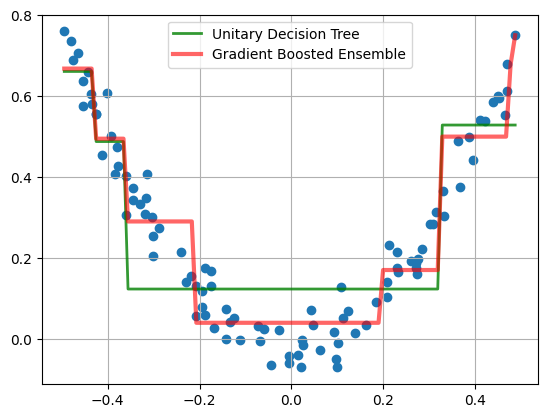

In [84]:
plt.scatter(X,y, linestyle= "None")

x1 = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_pred_tree= tree_reg1.predict(x1)
y_pred_gd= sum(tree.predict(x1) for tree in (tree_reg1, tree_reg2, tree_reg3))
plt.grid()

plt.plot(x1, y_pred_tree, linewidth=2, color= "green", alpha= 0.8,  label= "Unitary Decision Tree")
plt.plot(x1, y_pred_gd, linewidth = 3, color= "red", alpha= 0.6, label = "Gradient Boosted Ensemble")

plt.legend()

You can clearly see the difference, using graident boosted with reidual errors gives the model a higher variance, which was needed in this case 

In [82]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt= GradientBoostingRegressor(
    max_depth=2, n_estimators=3, 
    learning_rate=1.0, random_state=42
)
gbrt.fit(X, y) 

GradientBoostingRegressor(learning_rate=1.0, max_depth=2, n_estimators=3,
                          random_state=42)

How to find the best gbrt estimator?? Use the **n_iteration_no_change parameter**

In [89]:
gbrt_pred = gbrt.predict(X)
basic_gbrt_rmse = root_mean_squared_error(y, gbrt_pred)
basic_gbrt_rmse

0.07097928528094154

In [91]:
gbrt_best= GradientBoostingRegressor(
    max_depth=2, learning_rate=0.1, n_estimators=500, 
    n_iter_no_change=10, random_state=42
)
gbrt_best.fit(X,y)

gbrt_best_pred = gbrt_best.predict(X)
gbrt_rmse = root_mean_squared_error(y, gbrt_best_pred)
gbrt_rmse

0.033863547594020466

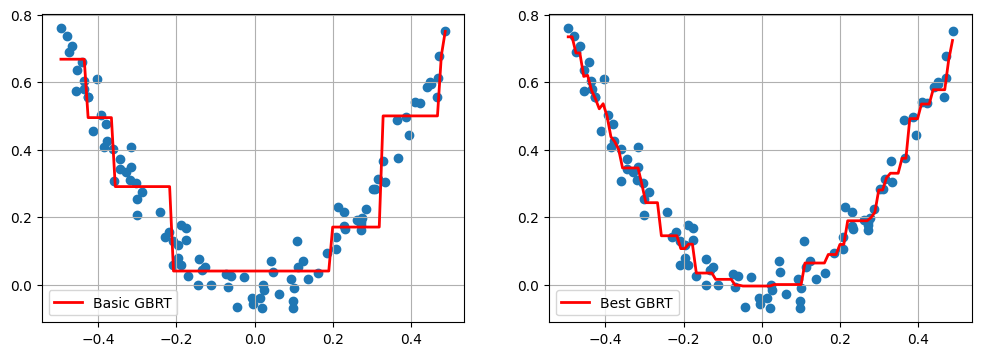

In [101]:
fig, axes= plt.subplots(1, 2, figsize= (12,4))

x1 = np.linspace(X.min(), X.max(), 100).reshape(-1,1)  

plt.sca(axes[0])
gbrt_x1= gbrt.predict(x1)
plt.scatter(X,y, linestyle= "None")
plt.plot(x1, gbrt_x1, color= "red", linewidth=2, label = "Basic GBRT")

plt.grid()
plt.legend()

plt.sca(axes[1])
gbrt_bx1= gbrt_best.predict(x1)
plt.scatter(X,y, linestyle= "None")
plt.plot(x1, gbrt_bx1, color= "red", linewidth=2, label = "Best GBRT")

plt.grid()
plt.legend()

In [100]:
gbrt_best.n_estimators_

57

### Using a Blender

We might as well try modelling our ensemble, in the sense that instead of specifying hard voting/ soft voting, just replace that with a model which can adjust as needed

In [104]:
from sklearn.ensemble import StackingClassifier

stacking_clf= StackingClassifier(
    estimators= [
        ('lr', LogisticRegression()),
        ('rf', RandomForestClassifier()),
        ('svc', SVC(probability= True))
    ],
    final_estimator= RandomForestClassifier(),
    cv= 5
)

stacking_clf.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('lr', LogisticRegression()),
                               ('rf', RandomForestClassifier()),
                               ('svc', SVC(probability=True))],
                   final_estimator=RandomForestClassifier())

In [105]:
stacking_clf.score(X_test, y_test)

0.92